# Módulo 4 — Inferencia estadística

> Curso de Python para Análisis de Datos en Salud Pública — OPS/PAHO
> Material 2021, actualizado 2026.
> Licencia: código MIT, contenido CC-BY-SA 4.0.


# Módulo 6: Nociones de inferencia estadística

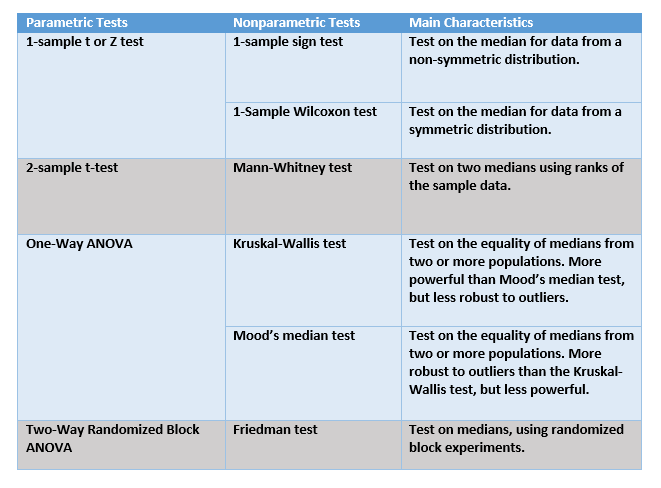

In [ ]:
# Usaremos nuestra base de los simpsons
covid_cases = {
    'edad' :     [ 66, 66, 33, 43, 41, 51, 84,119,51,68,92,69,42,70,45,63,77,68,76,71,71],
    'sexo' : [ 'M', 'F', 'F', 'M', 'F', 'M', 'M','M','M','M','M','M','M','F','M','M','M','M','M','F','F'],
    'nac_pac' :   [ 'COLOMBIA','ECUADOR','COLOMBIA', 'ECUADOR', 'COLOMBIA', 'ECUADOR', 'PERÚ','COLOMBIA', 'ECUADOR', 'COLOMBIA', 'ECUADOR','COLOMBIA','PERÚ','VENEZUELA','PERÚ','INDIA','VENEZUELA','VENEZUELA','ESCOCIA','ECUADOR','ECUADOR'],
    'area_ubi' :  [ 'Centro', 'Centro', 'Centro', 'Centro', 'Norte', 'Centro', 'Norte','Norte','Sur','Sur','Occidente','Oriente','Oriente','Occidente','Oriente','Sur','Centro','Oriente','Centro','Sur','Sur'],
    }
covid_cases

In [ ]:
# Se puede crear un data frame proporcionando los datos y estableciendo un índice. Si no se establece este será una sucesión de números
df = pd.DataFrame(covid_cases, index = ['Homero',"March","Magie",'Bart','Lisa','Lenny','Ned', 'Sr. Burns', 'Carl','Sr. Smithers','Krusty','Skinner','Milhouse','Edna Krabappel','Nelson','Apu','Moe','Jefe Górgory','Willie','Patty','Selma'])
df

In [ ]:
# Ampliamos la base para tener más de 30 observaciones
# Se necesitan al menos 30 para usar las pruebas con la distribución normal
df = pd.concat([df,df,df,df,df,df], axis=0)

In [ ]:
# Creamos la variable nombre, de acuerdo con el index
df['nombre'] = df.index

In [ ]:
# Reiniciamos el índice para que sean números
df = df.reset_index()

In [ ]:
# Confirmamos la dimensión de la base
df.shape

In [ ]:
# Crearemos una variable normal a propósito
# Con la semilla ('seed') establecemos un número que nos permita reproducir 
# el valor pseudo-aleatorio de np.random.normal. 
import random
np.random.seed(123)
df['gasto'] = (np.random.normal(loc=0.0,scale=1.0,size=126))+1

In [ ]:
np.random.seed(11) 
df['gasto_2'] = (np.random.normal(loc=0.0,scale=1.0,size=126))+1

In [ ]:
# Observamos la base
df.head()

## Prueba de normalidad


Más información:

[How to Test for Normality in Python (4 Methods)](https://www.statology.org/normality-test-python/)

[Normality Test](https://www.pythonfordatascience.org/independent-samples-t-test-python/#assumption_check)

In [ ]:
# Importando librerías para inferencia estadística
import scipy.stats
from scipy.stats import kstest

In [ ]:
# Comprobaremos si la edad muestra una distribución normal
# El test de Shapiro arroja que la variable se distribuye normalmente
# Pero advierte que el p-valor puede no ser preciso cuando la muestra es mayor a 5 mil
stats.shapiro(df['gasto'])


In [ ]:
# También podemos ver la distribución de los datos
sns.displot(df, x="gasto", kind="kde", fill=True)
plt.show()

## Prueba de diferencia de medias - Métodos paramétricos

La edad por lo general no se comporta de forma normal en múltiples bases de datos. Cuando existen dudas sobre la normalidad de las variables se deben preferir los tests no paramétricos. A continuación ilustramos cómo se realizan los tests paramétricos solo con fines ilustrativos.

Más información en:

[Z-Test](https://www.statology.org/z-test-python/)

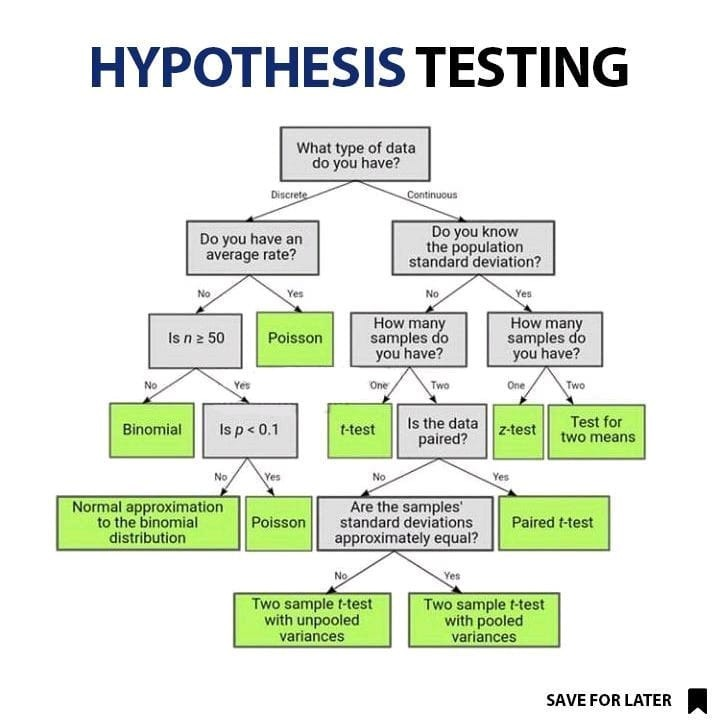



### Prueba Z con la distribución normal

Se usa cuando se conoce la desviación estándard y se tienen más de 30 observaciones.

In [ ]:
# Cargamos la librería y vemos el promedio real de la variable
from statsmodels.stats.weightstats import ztest as ztest

df['gasto'].mean()

In [ ]:
# Hacemos una prueba de diferencia del promedio respecto del valor muestral
# Obtenemos un p-valor mayor a 0.05, por lo que no se puede rechazar la hipótesis nula
# No hay suficiente evidencia estadística para indicar que el promedio es diferente de -0.05

ztest(df['gasto'], value=1)

In [ ]:
# Probaremos si el gasto promedio es 5
# El p-valor es 0.0, la evidencia estadística permite rechazar la hipótesis nula
# Por lo tanto, se concluye que la edad promedio es diferente de 5
ztest(df['gasto'], value=5)

In [ ]:
# Podemos observar que hay diferencia el gasto por área
df.groupby(['sexo'])['gasto'].mean()

In [ ]:
# Prueba de una muestra
# Probaremos si la media del gasto es igual a algún valor otorgado
# Como el P-valor es mayor a 0.05 no podemos rechazar la hipótesis nula de igualdad de medias
# Concluimos que la diferencia es estadísticamente no significativa

ztest(df['gasto'][df['sexo'] == 'M'],df['gasto'][df['sexo'] == 'F'], value=0)


In [ ]:
# Probaremos con la diferencia del gasto entre áreas

df.groupby(['area_ubi'])['gasto'].mean()

In [ ]:
# Comparamos el gasto de las personas del norte
# Con la media del gasto de las demás, las que no son del norte
# Como el p-valor es mayor a 0.05 podemos concluir que
# la evidencia estadística no respalda la diferencia de medias

ztest(df['gasto'][df['area_ubi'] == 'Oriente'],df['gasto'][df['area_ubi'] != 'Oriente'], value=0)


In [ ]:
# Podemos ver la densidad de la variable y observar las diferencia
sns.displot(df, x="gasto", hue="area_ubi", kind="kde")
plt.show()

### Prueba con la distribución T-Student

La distribución T de Student tiene colas más pesadas y se comporta mejor que la Z cuando tenemos pocos o menos datos. Cuando contamos con bastantes observaciones ambas se comportan muy parecido.

Esta se usa cuando no se conoce la desviación estándar.

Más información:

[Independent T-TEST](https://www.pythonfordatascience.org/independent-samples-t-test-python/)

[Comparing Two Means](https://ethanweed.github.io/pythonbook/05.02-ttest.html)

In [ ]:
# Cargamos la librería y recordamos el promedio con una muestra
import scipy.stats as stats

df['gasto'].mean()

In [ ]:
# El P-valor no permite rechazar la hipótesis nula
# Por lo tanto, la diferencia no es estadísticamente significativa
stats.ttest_1samp(a=df['gasto'], popmean=1.1)

In [ ]:
# Podemos aplicar una prueba t de diferencia de medias
# Se pasan como elementos las dos variables filtradas según el área
# Como el p-valor es superior a los niveles de error de 0.01, 0.05 y 0.1
# Se indica que no hay suficientes evidencia estadística
# para concluir que hay una diferencia estadísticamentes significativa 

stats.ttest_ind(df['gasto'][df['area_ubi'] == 'Oriente'],
                df['gasto'][df['area_ubi'] != 'Oriente'])

In [ ]:
# Observamos las medias
# Compararemos entre el norte y todo lo demás
df.groupby(['area_ubi'])['gasto'].mean()

### Prueba T-Student para muestras pareadas

Usamos esta opción cuando por ejemplo tomamos dos mediciones en la misma población en períodos distintos. Los datos en este caso están pareados porque provienen de la misma muestra.

Más información en:

[Prueba t para muestras pareadas](https://bookdown.org/dietrichson/metodos-cuantitativos/prueba-t-para-muestras-pareadas.html)

In [ ]:
# En este caso podemos usar el gasto y gasto_2 como dos datos apareados
# Observamos que el p_valor es superior a 0.05
# No hay suficiente evidencia estadística para rechazar que sean iguales
# tanto la media inicial y la segunda.

# Si este fuera un estudio clínico, la intervención no produjo un efecto
# estadísticamente significativo

stats.ttest_rel(df['gasto'], df['gasto_2'])

### Diferencia de medias entre varias poblaciones - Anova

Usamos el ANOVA o Análisis de Varianza para determinar si existe una diferencia significativa entre las medias de un grupo.

In [ ]:
# Importamos la librería oneway para realizar la prueba
from scipy.stats import f_oneway

# Seguiremos usando el gasto por área
# Recordamos los datos
df.groupby(['area_ubi'])['gasto'].mean()

In [ ]:
# Generaremos una segmentación de los datos
# Podemos crear nuevas variables, o simplemente condicionarlo
# Como el p-valor es mayor a los criterios 0.01, 0.05 y 0.1
# Podemos indicar que no se puede rechazar la hipótesis nula
# Por lo tanto no hay diferencias estadísticamente significativas

f_oneway(df['gasto'][df['area_ubi'] == 'Norte'],
         df['gasto'][df['area_ubi'] == 'Centro'],
         df['gasto'][df['area_ubi'] == 'Occidente'],
         df['gasto'][df['area_ubi'] == 'Oriente'],
         df['gasto'][df['area_ubi'] == 'Sur']    
)

## Prueba de diferencia de medias - Métodos no paramétricos

Se usan cuando la distribución es no normal.

Más información en:

[How to Calculate Nonparametric Statistical Hypothesis Tests in Python](https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/)



---



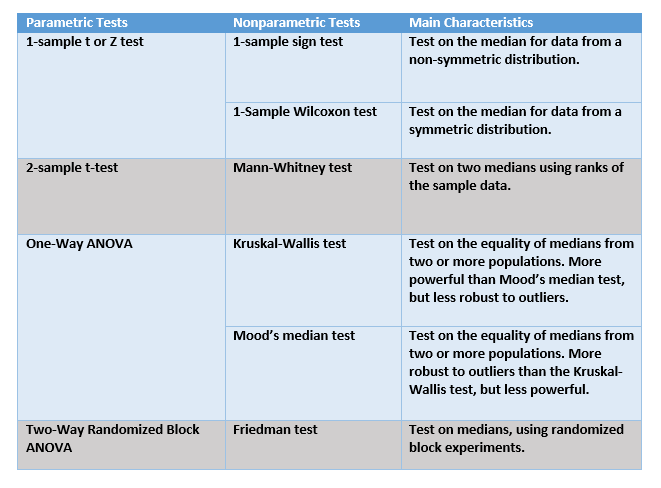

In [ ]:
# Probaremos si la distribución de la edad es normal
# Según el P-valor se puede rechazar la hipótesis nula sobre la normalidad
stats.shapiro(df['edad'])

In [ ]:
# Claramente se observa que la edad es no normal
# Pues no sigue una forma como la campana de gauss
sns.displot(df, x="edad", kind="kde", fill=True)
plt.show()

### Prueba de Mann-Whitney U

Esta es una prueba no paramétrica que prueba si la distribución de una variable x es la misma que la variable y, ordenándolas en orden de modo que si provienen de la misma población deberían estar entrelazadas.

Probaremos si la edad entre hombres y mujeres se comporta así y no hay diferencias significativas.

In [ ]:
# Recordemos los datos
df.groupby(['sexo'])['edad'].mean()

In [ ]:
# Cargamos la librería
# El resultado parece indicar que el gasto en hombres y mujeres provienen de
# poblaciones diferentes, por lo tanto son distintos
from scipy.stats import mannwhitneyu
mannwhitneyu(df['gasto'][df['sexo'] == 'M'],df['gasto'][df['sexo'] == 'F'], method="exact")


### Prueba de Wilcoxon para muestras pareadas

Más información en:

[Wilcoxon Sign-Ranked Test](https://pythonfordatascienceorg.wordpress.com/wilcoxon-sign-ranked-test-python/)

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html

In [ ]:
#Recordemos la edad promedio
df['edad'].mean()

In [ ]:
# Cargo la librería
from scipy.stats import wilcoxon

# Calculo la diferencia entre las observaciones
d=df['gasto']-df['gasto_2']

# Calculamos la prueba
wil_test = wilcoxon(d)
wil_test.statistic, wil_test.pvalue

# Como el valor es superior a los criterios 0.01, 0.05 y 0.1
# Concluimos que no se puede rechazar la hipótesis nula y que no hay diferencias

### Prueba de Kruskal Wallis para múltiples muestras


In [ ]:
# Importamos la librería
# El p-valor indica que se puede rechazar la hipótesis nula
# Por lo tanto, al menos uno de los datos no proviene de la misma población
# Se entiende entonces que al menos la edad en algún área es distinta a las demás

from scipy.stats import kruskal
kruskal(df['edad'][df['area_ubi'] == 'Norte'],
         df['edad'][df['area_ubi'] == 'Centro'],
         df['edad'][df['area_ubi'] == 'Occidente'],
         df['edad'][df['area_ubi'] == 'Oriente'],
         df['edad'][df['area_ubi'] == 'Sur'])

 

In [ ]:
# Podemos observar que efectivamente la edad difiere bastante
# entre las áreas

sns.displot(df, x="edad", kind="kde", hue='area_ubi', fill=True)
plt.show()

## Test de Poisson para ocurrencia de casos

In [ ]:
# Consultar a Diana
df.groupby(['area_ubi'])['gasto'].count()